# Uninsured Idiosyncratic Risk and Aggregate Saving

**Original paper:** *Uninsured Idiosyncratic Risk and Aggregate Saving* (1994), S. Rao Aiyagari.

**Implementation author:** André Chadú.

## Model summary

The Aiyagari model is a heterogeneous-agent incomplete-markets economy. Households face idiosyncratic labor-income risk that cannot be fully insured, choose savings subject to a borrowing constraint, and accumulate a risk-free asset for self-insurance. A competitive firm rents capital and hires labor. In equilibrium, the stationary distribution of household assets and income states determines aggregate capital, while factor prices must be consistent with firms' first-order conditions and household saving decisions. This notebook will solve the household problem, compute the stationary distribution, and find the general-equilibrium interest rate and capital stock.

In [1]:
# Core packages for the Aiyagari model implementation

#%pip install numpy scipy matplotlib ipykernel
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, sparse
from scipy.stats import norm


## The household consumption-savings problem

### Environment and budget constraint

Each household receives idiosyncratic labor income $w_t s_t$, where $s_t$ follows an exogenous Markov process. The household can only trade a one-period risk-free asset. Let $a_t$ be assets carried into period $t$, and let $a_{t+1}$ be the asset position chosen for the next period. A negative asset position is debt. At this stage, wages and interest rates may vary over time, so the period budget constraint is

$$c_t + a_{t+1} = w_t s_t + (1+r_t)a_t,$$

or, equivalently,

$$c_t = w_t s_t + (1+r_t)a_t - a_{t+1}.$$

The household faces an exogenous borrowing constraint

$$a_{t+1} \geq -\phi, \qquad \phi \geq 0,$$

and $a_0$ is given. Therefore, the recursive choice of $a_{t+1}$ determines how current resources are split between consumption and savings. The natural debt limit is the largest debt that can be repaid even if consumption is set to zero and income remains at its minimum value. Iterating the budget constraint forward gives

$$a_t \geq -\sum_{j=0}^{\infty} \frac{w_{t+j}s_{t+j}^{\min}}{\prod_{k=0}^{j}(1+r_{t+k})}.$$

In the numerical model, the imposed bound $-\phi$ must be no looser than this natural limit, so that feasible plans satisfy the intertemporal budget constraint.

### Sequential problem

The household solves

$$\max_{\{c_t,a_{t+1}\}_{t=0}^{\infty}} \; \mathbb{E}_0\sum_{t=0}^{\infty} \beta^t u(c_t)$$

subject to the budget constraint, $a_{t+1} + \phi \geq 0$, and $c_t \geq 0$ for every $t$. We assume $0<\beta<1$ and a strictly increasing, strictly concave utility function. The technical requirement $1+r_t>0$ guarantees that the gross return on the safe asset is positive. When we later impose a stationary equilibrium, $r_t=r$, the economically important restriction is $\beta(1+r)<1$. It ensures that the household is sufficiently impatient relative to the asset return and rules out unbounded asset accumulation. In the standard Aiyagari calibration, the equilibrium interest rate is positive.

### Lagrangian and KKT conditions

Let $\lambda_t$ be the multiplier on the budget constraint and let $\mu_t \geq 0$ be the multiplier on the borrowing constraint. Using the sign convention $a_{t+1}+\phi \geq 0$, the sequential Lagrangian is

$$\mathcal{L}=\mathbb{E}_0\sum_{t=0}^{\infty}\left\{\beta^t u(c_t) + \lambda_t\left[w_t s_t+(1+r_t)a_t-c_t-a_{t+1}\right] + \mu_t(a_{t+1}+\phi)\right\}.$$

The KKT conditions are obtained as follows.

1. **Choice of consumption.** Differentiating with respect to $c_t$ gives

$$\frac{\partial \mathcal{L}}{\partial c_t}=\beta^t u'(c_t)-\lambda_t=0,$$

so the multiplier on wealth is

$$\lambda_t=\beta^t u'(c_t).$$

2. **Choice of next-period assets.** The variable $a_{t+1}$ appears negatively in the period-$t$ budget constraint, positively in the borrowing constraint, and positively in period $t+1$ resources. Its first-order condition is

$$-\lambda_t + \mathbb{E}_t\left[(1+r_{t+1})\lambda_{t+1}\right] + \mu_t = 0.$$

The conditional expectation applies to the entire payoff from the asset because $a_{t+1}$ is chosen at time $t$, while both the future multiplier $\lambda_{t+1}$ and, in a non-stationary economy, the future return $r_{t+1}$ may depend on tomorrow's state. Substituting $\lambda_t=\beta^t u'(c_t)$ and $\lambda_{t+1}=\beta^{t+1}u'(c_{t+1})$ yields

$$u'(c_t)=\beta\mathbb{E}_t\left[(1+r_{t+1})u'(c_{t+1})\right]+\frac{\mu_t}{\beta^t}.$$

Define the date-$t$ normalized multiplier $\widetilde{\mu}_t=\mu_t/\beta^t$. The Euler inequality is therefore

$$u'(c_t)=\beta\mathbb{E}_t\left[(1+r_{t+1})u'(c_{t+1})\right]+\widetilde{\mu}_t,$$

with $\widetilde{\mu}_t\geq0$.

3. **Primal feasibility.**

$$c_t+a_{t+1}=w_t s_t+(1+r_t)a_t, \qquad a_{t+1}+\phi\geq0.$$

4. **Dual feasibility and complementary slackness.**

$$\widetilde{\mu}_t\geq0, \qquad \widetilde{\mu}_t(a_{t+1}+\phi)=0.$$

If $a_{t+1}>-\phi$, the constraint is slack, $\widetilde{\mu}_t=0$, and the standard Euler equation holds:

$$u'(c_t)=\beta\mathbb{E}_t\left[(1+r_{t+1})u'(c_{t+1})\right].$$

If $a_{t+1}=-\phi$, the constraint binds and $\widetilde{\mu}_t>0$. Marginal utility today is then larger than the discounted expected marginal utility from saving, because the household would like to borrow more but is prevented from doing so.

### Specialization to a stationary equilibrium

We now specialize the dynamic household problem to a stationary equilibrium. There are no aggregate shocks in the baseline Aiyagari economy: technology, preferences, the income transition matrix, and the aggregate distribution of households are time-invariant. Consequently, aggregate capital and labor are constant. Competitive firms therefore pay constant factor prices, implying

$$w_t=w, \qquad r_t=r, \qquad \text{for every } t.$$

Individual income risk remains stochastic because $s_t$ continues to move according to its Markov process. Stationarity means that prices and the cross-sectional distribution are invariant over time; it does not mean that an individual household's income or consumption is constant.

With constant prices, the budget constraint becomes

$$c_t+a_{t+1}=w s_t+(1+r)a_t.$$

The first-order condition for next-period assets simplifies from the general form to

$$-\lambda_t+(1+r)\mathbb{E}_t[\lambda_{t+1}]+\mu_t=0.$$

Using $\lambda_t=\beta^t u'(c_t)$ and $\widetilde{\mu}_t=\mu_t/\beta^t$, the stationary-equilibrium Euler inequality is

$$u'(c_t)=\beta(1+r)\mathbb{E}_t[u'(c_{t+1})]+\widetilde{\mu}_t.$$

Together with

$$\widetilde{\mu}_t\geq0, \qquad a_{t+1}+\phi\geq0, \qquad \widetilde{\mu}_t(a_{t+1}+\phi)=0,$$

this gives the stationary KKT system. If the borrowing constraint is slack, then $\widetilde{\mu}_t=0$ and

$$u'(c_t)=\beta(1+r)\mathbb{E}_t[u'(c_{t+1})].$$

For CRRA utility, $u(c)=c^{1-\sigma}/(1-\sigma)$, the interior Euler equation is

$$c_t^{-\sigma}=\beta(1+r)\mathbb{E}_t[c_{t+1}^{-\sigma}].$$

## CRRA preferences, risk aversion, and prudence

From this point onward, we assume constant-relative-risk-aversion (CRRA) utility:

$$u(c)=\begin{cases}\dfrac{c^{1-\sigma}-1}{1-\sigma}, & \sigma\neq1,\\[6pt]\log(c), & \sigma=1,\end{cases} \qquad c>0, \quad \sigma>0.$$

The additive constant $-1/(1-\sigma)$ is economically irrelevant; it is included only as a convenient normalization. The derivatives are

$$u'(c)=c^{-\sigma}>0,$$

$$u''(c)=-\sigma c^{-\sigma-1}<0,$$

and

$$u'''(c)=\sigma(\sigma+1)c^{-\sigma-2}>0.$$

These properties provide the two preference ingredients needed for the Aiyagari model. First, $u''(c)<0$ implies **risk aversion**: households dislike consumption risk and therefore value consumption smoothing. Relative risk aversion is constant and equal to

$$-\frac{c u''(c)}{u'(c)}=\sigma.$$

Second, $u'''(c)>0$ implies **prudence**: marginal utility $u'(c)$ is convex, so an increase in uninsurable future income risk raises the value of precautionary saving. Absolute prudence is

$$-\frac{u'''(c)}{u''(c)}=\frac{\sigma+1}{c}>0.$$

Thus, CRRA preferences generate both the desire to smooth realized income shocks and the precautionary motive to accumulate assets before shocks occur. These forces are central to the endogenous wealth distribution in the Aiyagari economy. In addition, $u'(c)\to\infty$ as $c\to0$, so the household strongly avoids zero consumption whenever a feasible positive-consumption choice exists.


## From the sequential problem to the Bellman equation

### State variables, controls, and the recursive representation

In the stationary partial-equilibrium household problem, take $w$ and $r$ as given. At the beginning of a period, the household observes its inherited assets $a$ and current income state $s$. These two variables summarize all payoff-relevant individual history: assets determine current resources, and $s$ determines current labor income and the distribution of tomorrow's income. The state is therefore $(a,s)$.

The household chooses current consumption $c$ and next-period assets $a'$. Since the current budget constraint determines consumption once $a'$ is chosen, it is convenient to use $a'$ as the sole continuous control:

$$c=(1+r)a+ws-a'.$$

Let $\Pi(s'\mid s)$ denote the Markov transition probability from current state $s$ to next-period state $s'$. The feasible set for next-period assets is

$$\Gamma(a,s)=\left\{a' : -\phi\leq a'\leq(1+r)a+ws\right\}.$$

The lower bound is the borrowing constraint. The upper bound follows from $c\geq0$: the household cannot save more than its current resources.

### Deriving the Bellman equation

Start from lifetime utility at the beginning of period $t$:

$$V(a_t,s_t)=\max_{\{c_{t+j},a_{t+j+1}\}_{j=0}^{\infty}}\mathbb{E}_t\left[\sum_{j=0}^{\infty}\beta^j u(c_{t+j})\right].$$

Separate the current payoff from the continuation value:

$$V(a_t,s_t)=\max_{c_t,a_{t+1}}\left\{u(c_t)+\beta\mathbb{E}_t\left[\max_{\{c_{t+1+j},a_{t+2+j}\}_{j=0}^{\infty}}\sum_{j=0}^{\infty}\beta^j u(c_{t+1+j})\right]\right\}.$$

Because the environment is stationary and the income process is Markov, the problem beginning next period has exactly the same functional form as today's problem. The expression inside the expectation is therefore $V(a_{t+1},s_{t+1})$. Conditional on the current income state, its expectation is

$$\mathbb{E}_t[V(a_{t+1},s_{t+1})]=\sum_{s'\in\mathcal{S}}\Pi(s'\mid s_t)V(a_{t+1},s').$$

Dropping time subscripts and substituting the budget constraint into utility gives the Bellman equation:

$$V(a,s)=\max_{a'\in\Gamma(a,s)}\left\{u\left((1+r)a+ws-a'\right)+\beta\sum_{s'\in\mathcal{S}}\Pi(s'\mid s)V(a',s')\right\}.$$

The associated asset policy function is

$$g_a(a,s)\in\arg\max_{a'\in\Gamma(a,s)}\left\{u\left((1+r)a+ws-a'\right)+\beta\sum_{s'}\Pi(s'\mid s)V(a',s')\right\},$$

and the consumption policy follows from the budget constraint:

$$g_c(a,s)=(1+r)a+ws-g_a(a,s).$$

This recursive formulation is equivalent to the sequential problem, but it is computationally useful because it maps a candidate value function into an updated value function. Value function iteration repeatedly applies this Bellman operator until it reaches a fixed point. Later, once $r$ is found such that the asset market clears, this partial-equilibrium household solution becomes part of the stationary general equilibrium.

## Closing the model: firms, the stationary distribution, and market clearing

The household Bellman problem is a **partial-equilibrium** problem: it takes the wage $w$ and interest rate $r$ as given. To determine these prices endogenously, Aiyagari (1994) adds a competitive production sector and requires all markets to clear.

### Firms and factor prices

A representative competitive firm produces with a constant-returns-to-scale Cobb--Douglas technology:

$$Y=F(K,L)=K^\alpha L^{1-\alpha}, \qquad 0<\alpha<1.$$

Here $K$ is aggregate physical capital and $L$ is aggregate efficiency units of labor. Capital depreciates at rate $\delta\in[0,1]$. Taking factor prices as given, the firm solves

$$\max_{K,L}\left\{F(K,L)-(r+\delta)K-wL\right\}.$$

The firm pays $r+\delta$ per unit of capital because a unit of capital must both compensate its owner by the net interest rate $r$ and replace depreciation $\delta$. The first-order conditions are

$$F_K(K,L)=r+\delta, \qquad F_L(K,L)=w.$$

For Cobb--Douglas production, they imply

$$r=\alpha\left(\frac{K}{L}\right)^{\alpha-1}-\delta, \qquad w=(1-\alpha)\left(\frac{K}{L}\right)^\alpha.$$

Thus the capital--labor ratio determines both prices. In particular, more aggregate capital lowers its marginal product and therefore lowers $r$, while raising $w$. This price feedback is what turns the household saving problem into a general-equilibrium model.

### The stationary distribution

Let $\lambda(a,s)$ be the stationary distribution of households over current assets and idiosyncratic income states. It is required because households with different histories choose different asset levels. Given the policy $g_a$ and the transition matrix $\Pi$, the distribution evolves according to the induced law of motion. In a stationary equilibrium it reproduces itself:

$$\lambda'=T_{g_a,\Pi}(\lambda)=\lambda.$$

In a discrete asset grid, this condition says that the mass arriving at each pair $(a',s')$ equals the mass already there:

$$\lambda(a',s')=\sum_{a\in\mathcal{A}}\sum_{s\in\mathcal{S}}\lambda(a,s)\,\mathbf{1}\{g_a(a,s)=a'\}\,\Pi(s'\mid s).$$

The distribution also determines aggregate labor and household asset supply:

$$L=\int_{\mathcal{A}\times\mathcal{S}} s\,d\lambda(a,s), \qquad A=\int_{\mathcal{A}\times\mathcal{S}} a\,d\lambda(a,s).$$

### The condition that closes the model

Households save by buying claims to capital, while firms demand capital to produce. Therefore the capital market clears only when aggregate household assets equal the capital used by firms:

$$\boxed{\int_{\mathcal{A}\times\mathcal{S}} a\,d\lambda(a,s)=K.}$$

Equivalently, because the distribution is stationary, next-period assets chosen by households must equal the same capital stock:

$$\int_{\mathcal{A}\times\mathcal{S}} g_a(a,s)\,d\lambda(a,s)=K.$$

This condition comes directly from accounting: every unit of household saving must finance a unit of productive capital, and every unit of capital demanded by firms must be owned by households. It selects the equilibrium interest rate. For a trial $r$, the firm condition determines $w$ (given $K/L$), households solve the Bellman equation, and their policy generates $\lambda$ and asset supply $A$. The equilibrium is the fixed point at which $A=K$ and the induced distribution is stationary.

A stationary competitive equilibrium is therefore a value function $V$, policy functions $(g_a,g_c)$, prices $(r,w)$, aggregates $(K,L)$, and a distribution $\lambda$ such that: households optimize; firms optimize; $\lambda$ is invariant under household decisions and income transitions; and the capital market-clearing condition above holds.

## Baseline Aiyagari model: summary

The baseline Aiyagari (1994) economy combines incomplete insurance against idiosyncratic labor-income risk with a neoclassical production sector. Because households cannot buy state-contingent insurance, they use a single risk-free asset to smooth consumption and build precautionary wealth.

### Production

Competitive firms produce output with a Cobb--Douglas technology:

$$Y=K^\alpha L^{1-\alpha}, \qquad 0<\alpha<1.$$

With depreciation $\delta$, firm optimization determines prices:

$$r=\alpha\left(\frac{K}{L}\right)^{\alpha-1}-\delta, \qquad w=(1-\alpha)\left(\frac{K}{L}\right)^\alpha.$$

### Idiosyncratic income and household problem

A household supplies efficiency units $e_t>0$. A common specification starts from log income,

$$s_t=\rho s_{t-1}+\sigma_\varepsilon\varepsilon_t, \qquad \varepsilon_t\sim\mathcal{N}(0,1), \qquad e_t=\exp(s_t),$$

and discretizes this process into a finite Markov chain with transition matrix $\Pi$. Given $(a,s)$ and prices $(r,w)$, the household solves

$$V(a,s)=\max_{a'\geq-\phi}\left\{u\left((1+r)a+w e(s)-a'\right)+\beta\sum_{s'\in\mathcal{S}}\Pi(s'\mid s)V(a',s')\right\},$$

where $c=(1+r)a+w e(s)-a'$ and $a'\geq-\phi$ is the borrowing constraint. In the notation used earlier, $s$ may itself denote the efficiency level, in which case replace $e(s)$ by $s$.

### Equilibrium

The saving policy and income transitions generate an invariant distribution $\lambda(a,s)$. The equilibrium interest rate is the rate that clears the capital market:

$$\int_{\mathcal{A}\times\mathcal{S}} a\,d\lambda(a,s)=K.$$

Thus household asset supply equals firms' capital demand. The prices, policies, distribution, and aggregates are jointly consistent at the stationary competitive equilibrium.

## Endogenous Grid Method (EGM)

The Endogenous Grid Method (Carroll, 2006) solves the household problem without numerically maximizing over next-period assets at every current-asset grid point. Instead, it uses the Euler equation to construct the **current** asset grid that is implied by a chosen grid for **next-period** assets.

### 1. Start from the Euler equation

For an unconstrained household with CRRA preferences,

$$c(a,s)^{-\sigma}=\beta(1+r)\sum_{s'\in\mathcal{S}}\Pi(s'\mid s)\,c\left(g_a(a,s),s'\right)^{-\sigma}.$$

Fix a grid point for next-period assets, $a'$, and use a previous consumption-policy iterate $c^{\mathrm{old}}(a',s')$. Expected next-period marginal utility is

$$\mathcal{M}(a',s)=\sum_{s'\in\mathcal{S}}\Pi(s'\mid s)\left[c^{\mathrm{old}}(a',s')\right]^{-\sigma}.$$

Inverting marginal utility yields current consumption directly:

$$c^{\mathrm{new}}(a',s)=\left[\beta(1+r)\mathcal{M}(a',s)\right]^{-1/\sigma}.$$

### 2. Build the endogenous grid

Use the budget constraint to infer the current asset level at which choosing this $a'$ is optimal:

$$a_{\mathrm{endo}}(a',s)=\frac{c^{\mathrm{new}}(a',s)+a'-w e(s)}{1+r}.$$

The pairs $\left(a_{\mathrm{endo}}(a',s),a'\right)$ are the saving policy on an **endogenous** current-asset grid. For each income state, interpolate these pairs back onto the fixed computational grid $a\in\mathcal{A}$ to obtain $g_a^{\mathrm{new}}(a,s)$, then recover

$$g_c^{\mathrm{new}}(a,s)=(1+r)a+w e(s)-g_a^{\mathrm{new}}(a,s).$$

### 3. Treat the borrowing constraint

The Euler equation is valid only when the borrowing constraint is slack. For current assets below the smallest endogenous point, set the constraint to bind:

$$g_a(a,s)=-\phi, \qquad g_c(a,s)=(1+r)a+w e(s)+\phi.$$

Repeat these steps until the policy converges. EGM is typically much faster than value-function iteration because it replaces a nested maximization with expectation, inversion of marginal utility, and interpolation. For general equilibrium, solve this household problem for a trial $r$, compute the invariant distribution and asset supply, and update $r$ until the capital market clears.

## EGM implementation: partial-equilibrium Aiyagari model

The following cells solve the household problem by EGM at fixed prices. The five efficiency states range from 0.50 to 1.50. A darker red always denotes a higher efficiency state. After inspecting these policy functions, the same solver can be embedded in the general-equilibrium loop described above.

In [2]:
# Parameters, income process, and EGM solver
beta = 0.96
r = 0.03
w = 1.00
sigma = 2.0
a_min, a_max, n_a = 0.0, 50.0, 500
a_grid = np.linspace(a_min, a_max, n_a)

# Five idiosyncratic efficiency states: darker red means higher income.
e_grid = np.array([0.50, 0.75, 1.00, 1.25, 1.50])
n_s = e_grid.size
reds = plt.cm.Reds(np.linspace(0.38, 0.92, n_s))

# Persistent Markov chain with a symmetric stationary distribution.
Pi = np.array([
    [0.875, 0.125, 0.000, 0.000, 0.000],
    [0.125, 0.750, 0.125, 0.000, 0.000],
    [0.000, 0.125, 0.750, 0.125, 0.000],
    [0.000, 0.000, 0.125, 0.750, 0.125],
    [0.000, 0.000, 0.000, 0.125, 0.875],
])
assert np.allclose(Pi.sum(axis=1), 1.0)

def solve_egm(beta, r, w, sigma, a_grid, e_grid, Pi, tol=1e-9, max_iter=5_000):
    '''Solve the constrained household problem by the endogenous grid method.'''
    n_a, n_s = a_grid.size, e_grid.size
    cash_on_hand = (1.0 + r) * a_grid[:, None] + w * e_grid[None, :]
    c = np.maximum(cash_on_hand - a_grid[0], 1e-12)

    for iteration in range(max_iter):
        expected_mu = (c ** (-sigma)) @ Pi.T
        c_endo = (beta * (1.0 + r) * expected_mu) ** (-1.0 / sigma)
        a_endo = (c_endo + a_grid[:, None] - w * e_grid[None, :]) / (1.0 + r)

        a_policy = np.empty_like(c)
        for i_s in range(n_s):
            # EGM produces pairs (current endogenous assets, next assets).
            x = a_endo[:, i_s]
            y = a_grid
            x_unique, keep = np.unique(x, return_index=True)
            y_unique = y[keep]
            a_policy[:, i_s] = np.interp(a_grid, x_unique, y_unique)
            # At low assets the borrowing constraint binds.
            a_policy[a_grid <= x_unique[0], i_s] = a_grid[0]

        c_new = np.maximum(cash_on_hand - a_policy, 1e-12)
        error = np.max(np.abs(c_new - c))
        c = c_new
        if error < tol:
            break
    else:
        raise RuntimeError('EGM did not converge; increase max_iter or revise parameters.')

    return a_policy, c, iteration + 1, error

a_policy, c_policy, egm_iterations, egm_error = solve_egm(
    beta, r, w, sigma, a_grid, e_grid, Pi
)
print(f'EGM converged in {egm_iterations} iterations; max policy change = {egm_error:.2e}.')


EGM converged in 365 iterations; max policy change = 9.56e-10.


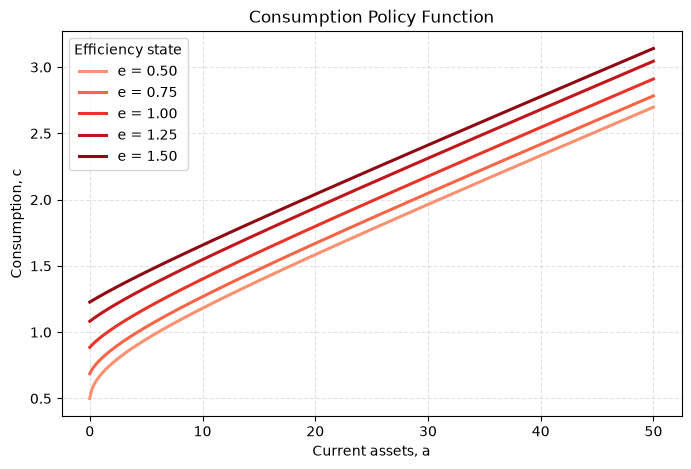

In [3]:
# Consumption policy functions
fig, ax = plt.subplots(figsize=(8, 5))
for i_s, efficiency in enumerate(e_grid):
    ax.plot(a_grid, c_policy[:, i_s], color=reds[i_s], lw=2.2,
            label=f'e = {efficiency:.2f}')
ax.set(title='Consumption Policy Function', xlabel='Current assets, a', ylabel='Consumption, c')
ax.grid(alpha=0.35, ls='--')
ax.legend(title='Efficiency state')
plt.show()


### Interpretation: consumption policies

At every asset level, a higher efficiency state shifts consumption upward because current labor income is higher. The policy functions are concave: households with little wealth save cautiously to protect consumption against future income risk, while wealthier households devote a larger share of additional resources to consumption. The dark-red curves therefore represent households with both higher current resources and, at a given asset level, greater consumption.

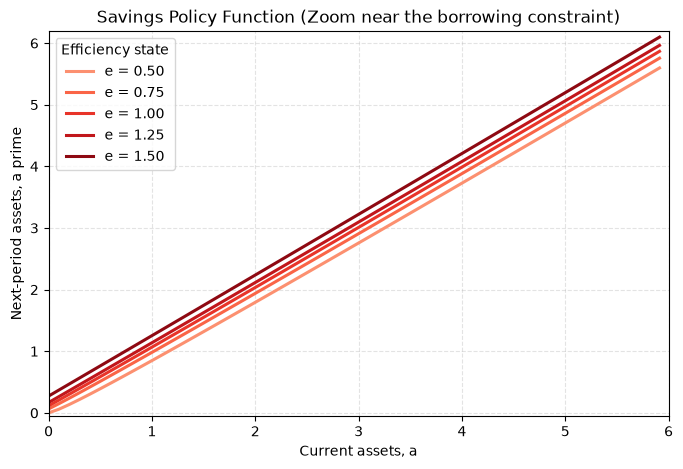

In [4]:
# Savings policy functions: zoom near the borrowing constraint
zoom_max = 6.0
zoom = a_grid <= zoom_max
fig, ax = plt.subplots(figsize=(8, 5))
for i_s, efficiency in enumerate(e_grid):
    ax.plot(a_grid[zoom], a_policy[zoom, i_s], color=reds[i_s], lw=2.2,
            label=f'e = {efficiency:.2f}')
ax.set(title='Savings Policy Function (Zoom near the borrowing constraint)',
       xlabel='Current assets, a', ylabel='Next-period assets, a prime', xlim=(0, zoom_max))
y_low = min(-0.02, a_policy[zoom, :].min() - 0.05)
y_high = a_policy[zoom, :].max() + 0.10
ax.set_ylim(y_low, y_high)
ax.grid(alpha=0.35, ls='--')
ax.legend(title='Efficiency state')
plt.show()


### Interpretation: savings policies

The zoom reveals the borrowing-constraint region that would be hard to see on the full asset range. Low-efficiency households at sufficiently low assets choose the borrowing limit, so their next-period assets are flat at zero. As income rises, the policy moves upward: high-efficiency households can save more out of the same current asset position. The kink where a curve leaves the lower bound marks the transition from constrained to unconstrained Euler-equation behavior.

Distribution converged in 1275 iterations; max change = 9.97e-13.


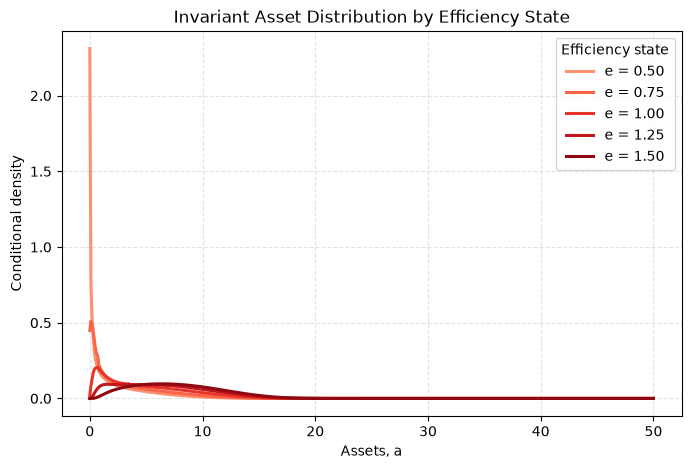

In [5]:
# Stationary distribution induced by the EGM policy
def stationary_distribution(a_policy, a_grid, Pi, tol=1e-12, max_iter=20_000):
    '''Forward-iterate the distribution using linear interpolation on the asset grid.'''
    n_a, n_s = a_policy.shape
    distribution = np.full((n_a, n_s), 1.0 / (n_a * n_s))

    for iteration in range(max_iter):
        next_distribution = np.zeros_like(distribution)
        for i_a in range(n_a):
            for i_s in range(n_s):
                mass = distribution[i_a, i_s]
                a_next = a_policy[i_a, i_s]
                upper = np.searchsorted(a_grid, a_next, side='right')
                upper = min(max(upper, 1), n_a - 1)
                lower = upper - 1
                weight_upper = (a_next - a_grid[lower]) / (a_grid[upper] - a_grid[lower])
                weight_lower = 1.0 - weight_upper
                next_distribution[lower, :] += mass * weight_lower * Pi[i_s, :]
                next_distribution[upper, :] += mass * weight_upper * Pi[i_s, :]

        error = np.max(np.abs(next_distribution - distribution))
        distribution = next_distribution
        if error < tol:
            break
    else:
        raise RuntimeError('The stationary distribution did not converge.')
    return distribution, iteration + 1, error

distribution, dist_iterations, dist_error = stationary_distribution(a_policy, a_grid, Pi)
state_mass = distribution.sum(axis=0)
conditional_density = distribution / state_mass[None, :] / (a_grid[1] - a_grid[0])
print(f'Distribution converged in {dist_iterations} iterations; max change = {dist_error:.2e}.')

fig, ax = plt.subplots(figsize=(8, 5))
for i_s, efficiency in enumerate(e_grid):
    ax.plot(a_grid, conditional_density[:, i_s], color=reds[i_s], lw=2.2,
            label=f'e = {efficiency:.2f}')
ax.set(title='Invariant Asset Distribution by Efficiency State',
       xlabel='Assets, a', ylabel='Conditional density')
ax.grid(alpha=0.35, ls='--')
ax.legend(title='Efficiency state')
plt.show()


### Interpretation: invariant distribution

The distribution is conditional on each efficiency state, so each curve shows where households in that state tend to be located on the asset grid. Mass near the borrowing limit reflects households hit by unfavorable income histories and unable to insure completely. Higher-efficiency states, shown in darker red, tend to be associated with distributions shifted toward greater asset holdings because their policy functions support stronger saving. The shape is an endogenous outcome of persistent income risk, precautionary saving, and the borrowing constraint.

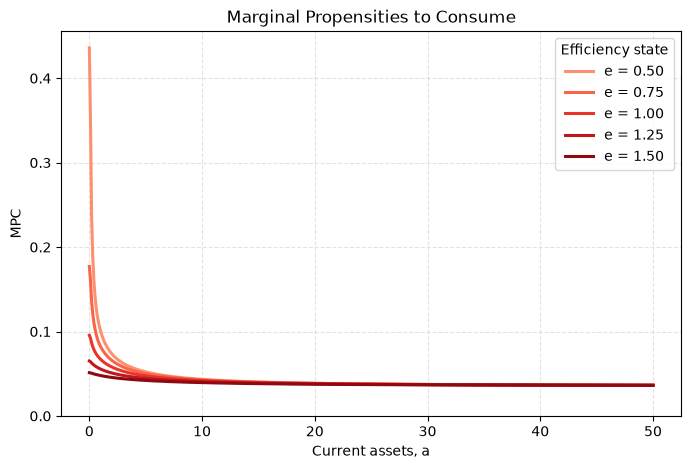

In [6]:
# Marginal propensities to consume (MPCs)
mpc = np.gradient(c_policy, a_grid, axis=0)
fig, ax = plt.subplots(figsize=(8, 5))
for i_s, efficiency in enumerate(e_grid):
    ax.plot(a_grid, mpc[:, i_s], color=reds[i_s], lw=2.2,
            label=f'e = {efficiency:.2f}')
ax.set(title='Marginal Propensities to Consume', xlabel='Current assets, a', ylabel='MPC')
ax.set_ylim(bottom=0)
ax.grid(alpha=0.35, ls='--')
ax.legend(title='Efficiency state')
plt.show()


### Interpretation: marginal propensities to consume

MPCs are highest near the borrowing constraint because a household with little wealth has few ways to spread an additional unit of resources across time. As assets rise, the household has more self-insurance and saves a larger portion of an incremental resource, reducing the MPC. Differences across red curves reflect how current income changes the tightness of the constraint and the strength of the precautionary motive. Small numerical irregularities at kinks are expected because the policies are computed on a discrete grid and then differentiated numerically.

## Borrowing limits: theory and the role of $\phi$

The borrowing constraint is written as

$a'\geq-\phi, \qquad \phi\geq0.$

The parameter $\phi$ is the maximum amount of debt a household may carry into the next period. When $\phi=0$, households cannot borrow. Increasing $\phi$ relaxes the constraint because it expands the feasible set for next-period assets.

For a given pair of prices $(r,w)$, the Bellman equation becomes

$V_{\phi}(a,s)=\max_{a'\geq-\phi}\left\{u\left((1+r)a+w e(s)-a'\right)+\beta\sum_{s'\in\mathcal{S}}\Pi(s'\mid s)V_{\phi}(a',s')\right\}.$

If $\phi_2>\phi_1$, every choice feasible under $\phi_1$ remains feasible under $\phi_2$. Consequently, at fixed prices, $V_{\phi_2}(a,s)\geq V_{\phi_1}(a,s)$. The Euler equation holds with equality only away from the limit; at $a'=-\phi$, the borrowing constraint binds and the household would like to borrow more.

The value of $\phi$ must remain below the natural debt limit, which rules out debt plans that can never be repaid even under the worst feasible income history.

## What changes in general equilibrium when $\phi$ varies?

A comparison that holds $r$ and $w$ fixed is a useful partial-equilibrium exercise, but it does not close the Aiyagari model. In general equilibrium, each value of $\phi$ requires a new fixed point:

1. Guess an interest rate $r$ and obtain capital demand and the wage from the firm's first-order conditions.
2. Solve the household problem by EGM with borrowing limit $-\phi$.
3. Compute the invariant distribution induced by the saving policy.
4. Aggregate household assets and update $r$ until asset supply equals firm capital demand.

Relaxing the borrowing limit typically reduces precautionary saving. This tends to lower the equilibrium capital stock. With Cobb--Douglas production, a lower capital--labor ratio generally raises the equilibrium interest rate and lowers the wage. The magnitude is quantitative, however, so the following code computes rather than assumes these effects.

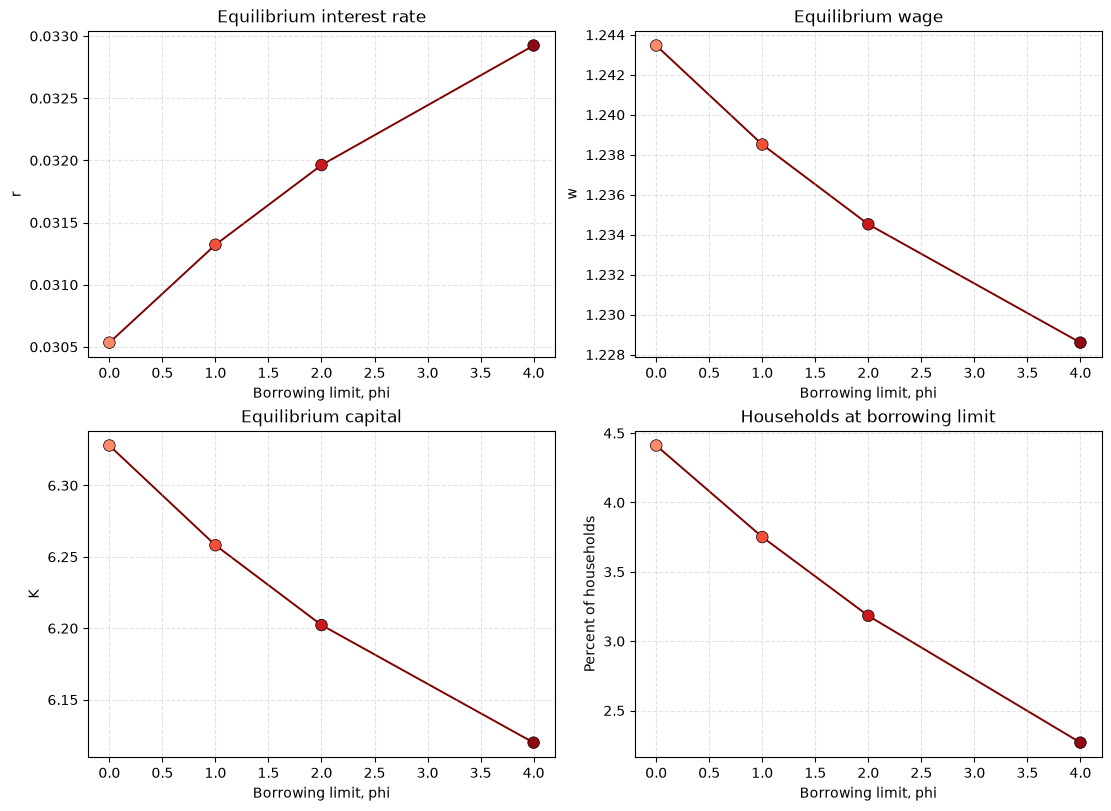

phi=0.0 | r=0.0305 | w=1.2435 | K=6.3279 | A=6.3291 | constrained=4.41%
phi=1.0 | r=0.0313 | w=1.2385 | K=6.2581 | A=6.2575 | constrained=3.75%
phi=2.0 | r=0.0320 | w=1.2345 | K=6.2022 | A=6.2014 | constrained=3.18%
phi=4.0 | r=0.0329 | w=1.2286 | K=6.1199 | A=6.1179 | constrained=2.27%


In [7]:
# General-equilibrium comparison across borrowing limits phi
# This cell is self-contained and can be run after a kernel restart.
import numpy as np
import matplotlib.pyplot as plt

beta, sigma = 0.96, 2.0
e_grid = np.array([0.50, 0.75, 1.00, 1.25, 1.50])
Pi = np.array([
    [0.875, 0.125, 0.000, 0.000, 0.000],
    [0.125, 0.750, 0.125, 0.000, 0.000],
    [0.000, 0.125, 0.750, 0.125, 0.000],
    [0.000, 0.000, 0.125, 0.750, 0.125],
    [0.000, 0.000, 0.000, 0.125, 0.875],
])

alpha, delta = 0.36, 0.08
phi_values = np.array([0.0, 1.0, 2.0, 4.0])
ge_colors = plt.cm.Reds(np.linspace(0.40, 0.92, phi_values.size))

def solve_egm_with_limit(beta, r, w, sigma, a_grid, e_grid, Pi, phi,
                         tol=2e-8, max_iter=2_000):
    '''EGM with a lower bound of -phi; the grid begins at that bound.'''
    lower_bound = -phi
    cash_on_hand = (1.0 + r) * a_grid[:, None] + w * e_grid[None, :]
    c = np.maximum(cash_on_hand - lower_bound, 1e-12)

    for iteration in range(max_iter):
        expected_mu = (c ** (-sigma)) @ Pi.T
        c_endo = (beta * (1.0 + r) * expected_mu) ** (-1.0 / sigma)
        a_endo = (c_endo + a_grid[:, None] - w * e_grid[None, :]) / (1.0 + r)
        a_policy = np.empty_like(c)

        for i_s in range(e_grid.size):
            x, keep = np.unique(a_endo[:, i_s], return_index=True)
            a_policy[:, i_s] = np.interp(a_grid, x, a_grid[keep])
            a_policy[a_grid <= x[0], i_s] = lower_bound
            a_policy[:, i_s] = np.maximum(a_policy[:, i_s], lower_bound)

        c_new = np.maximum(cash_on_hand - a_policy, 1e-12)
        if np.max(np.abs(c_new - c)) < tol:
            return a_policy, c_new
        c = c_new
    raise RuntimeError('EGM did not converge in the general-equilibrium loop.')

def stationary_distribution_fast(a_policy, a_grid, Pi, tol=2e-10, max_iter=10_000):
    '''Forward iteration, vectorized over the asset grid for each income state.'''
    n_a, n_s = a_policy.shape
    distribution = np.full((n_a, n_s), 1.0 / (n_a * n_s))

    for iteration in range(max_iter):
        next_distribution = np.zeros_like(distribution)
        for i_s in range(n_s):
            a_next = a_policy[:, i_s]
            upper = np.searchsorted(a_grid, a_next, side='right')
            upper = np.clip(upper, 1, n_a - 1)
            lower = upper - 1
            weight_upper = (a_next - a_grid[lower]) / (a_grid[upper] - a_grid[lower])
            weight_lower = 1.0 - weight_upper
            mass = distribution[:, i_s]
            for i_next_s in range(n_s):
                transition_mass = mass * Pi[i_s, i_next_s]
                np.add.at(next_distribution[:, i_next_s], lower,
                          transition_mass * weight_lower)
                np.add.at(next_distribution[:, i_next_s], upper,
                          transition_mass * weight_upper)
        if np.max(np.abs(next_distribution - distribution)) < tol:
            return next_distribution
        distribution = next_distribution
    raise RuntimeError('Stationary distribution did not converge.')

def evaluate_interest_rate(r_guess, phi):
    '''Return excess asset supply and equilibrium objects for one trial rate.'''
    capital_demand = (alpha / (r_guess + delta)) ** (1.0 / (1.0 - alpha))
    wage = (1.0 - alpha) * capital_demand ** alpha  # Aggregate labor is normalized to one.
    a_grid_phi = np.linspace(-phi, 50.0, 350)
    a_pol, c_pol = solve_egm_with_limit(beta, r_guess, wage, sigma,
                                         a_grid_phi, e_grid, Pi, phi)
    dist = stationary_distribution_fast(a_pol, a_grid_phi, Pi)
    asset_supply = np.sum(dist * a_grid_phi[:, None])
    constrained_share = np.sum(dist[a_pol <= -phi + 1e-8])
    return asset_supply - capital_demand, (capital_demand, wage, asset_supply,
                                           constrained_share, a_grid_phi, a_pol, c_pol, dist)

def solve_general_equilibrium(phi, r_low=0.005, r_high=0.080, tol=2e-3, max_iter=35):
    '''Bisection on the asset-market-clearing condition A(r, phi) - K(r) = 0.'''
    excess_low, _ = evaluate_interest_rate(r_low, phi)
    excess_high, _ = evaluate_interest_rate(r_high, phi)
    if not (excess_low < 0 < excess_high):
        raise RuntimeError('The interest-rate bracket does not contain an equilibrium.')

    for _ in range(max_iter):
        r_mid = 0.5 * (r_low + r_high)
        excess_mid, objects = evaluate_interest_rate(r_mid, phi)
        if abs(excess_mid) < tol:
            return r_mid, objects
        if excess_mid > 0:
            r_high = r_mid
        else:
            r_low = r_mid
    return r_mid, objects

ge_results = []
ge_solutions = {}
for phi in phi_values:
    r_eq, objects = solve_general_equilibrium(phi)
    K_eq, w_eq, A_eq, constrained_share, *_ = objects
    ge_results.append((phi, r_eq, w_eq, K_eq, A_eq, constrained_share))
    ge_solutions[float(phi)] = objects

ge_results = np.array(ge_results)
phi_plot, r_plot, w_plot, K_plot, A_plot, constrained_plot = ge_results.T

fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
series = [
    (r_plot, 'Equilibrium interest rate', 'r'),
    (w_plot, 'Equilibrium wage', 'w'),
    (K_plot, 'Equilibrium capital', 'K'),
    (100 * constrained_plot, 'Households at borrowing limit', 'Percent of households'),
]
for ax, (values, title, ylabel) in zip(axes.flat, series):
    ax.plot(phi_plot, values, color='#7f0000', lw=1.4, zorder=1)
    ax.scatter(phi_plot, values, c=ge_colors, s=70, edgecolor='black', linewidth=0.5, zorder=2)
    ax.set(title=title, xlabel='Borrowing limit, phi', ylabel=ylabel)
    ax.grid(alpha=0.35, ls='--')
plt.show()

for phi, r_eq, w_eq, K_eq, A_eq, constrained_share in ge_results:
    print(f'phi={phi:>3.1f} | r={r_eq:.4f} | w={w_eq:.4f} | K={K_eq:.4f} | '
          f'A={A_eq:.4f} | constrained={100 * constrained_share:.2f}%')


### Interpretation: general-equilibrium effects of relaxing the borrowing limit

Read the panels jointly. Moving to the right relaxes the credit limit because households are allowed to choose more negative assets. If the precautionary-saving mechanism dominates, capital falls as $\phi$ rises; the Cobb--Douglas pricing equations then imply a higher interest rate and a lower wage. The last panel shows the distributional margin: it reports the share of households whose optimal asset choice is exactly the borrowing limit in each equilibrium.

The figure is a quantitative comparative static, not an imposed result. Its slopes depend on the calibration, the persistence and dispersion of idiosyncratic income, and the asset-grid accuracy. The equality of $A$ and $K$ in the printed table is the numerical check that each plotted point satisfies the asset-market-clearing condition.

## Policy functions across general-equilibrium borrowing limits

The next figures use the equilibrium objects stored in the general-equilibrium comparison. Run that cell immediately above before running these plots.

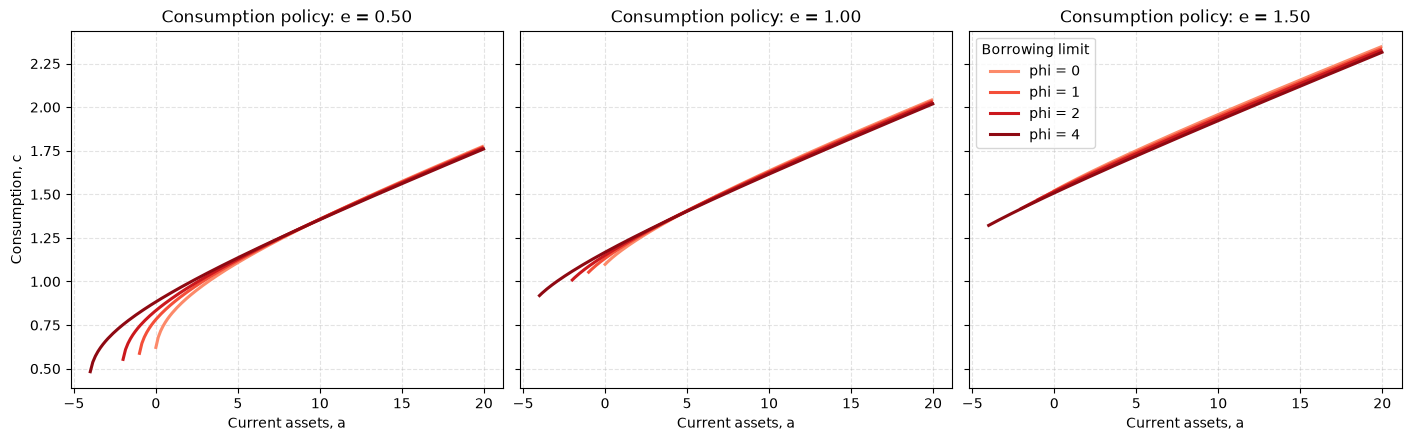

In [8]:
# Consumption policies across phi, at low, middle, and high efficiency states
selected_states = [0, 2, 4]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.3), sharey=True, constrained_layout=True)
for ax, i_s in zip(axes, selected_states):
    for phi, color in zip(phi_values, ge_colors):
        K_eq, w_eq, A_eq, constrained_share, a_grid_phi, a_pol, c_pol, dist = ge_solutions[float(phi)]
        visible = a_grid_phi <= 20.0
        ax.plot(a_grid_phi[visible], c_pol[visible, i_s], color=color, lw=2.2,
                label=f'phi = {phi:.0f}')
    ax.set(title=f'Consumption policy: e = {e_grid[i_s]:.2f}',
           xlabel='Current assets, a')
    ax.grid(alpha=0.35, ls='--')
axes[0].set_ylabel('Consumption, c')
axes[-1].legend(title='Borrowing limit')
plt.show()


### Interpretation: consumption policies across $\phi$

Relaxing the borrowing limit extends the feasible policy to negative asset positions. The comparison also incorporates the endogenous price changes: a larger $\phi$ raises the equilibrium interest rate but lowers the wage. Consequently, the vertical shift in consumption is a net general-equilibrium effect rather than only the direct benefit of easier credit. The differences are usually most pronounced for low-efficiency, low-asset households, whose ability to smooth adverse income realizations is most constrained.

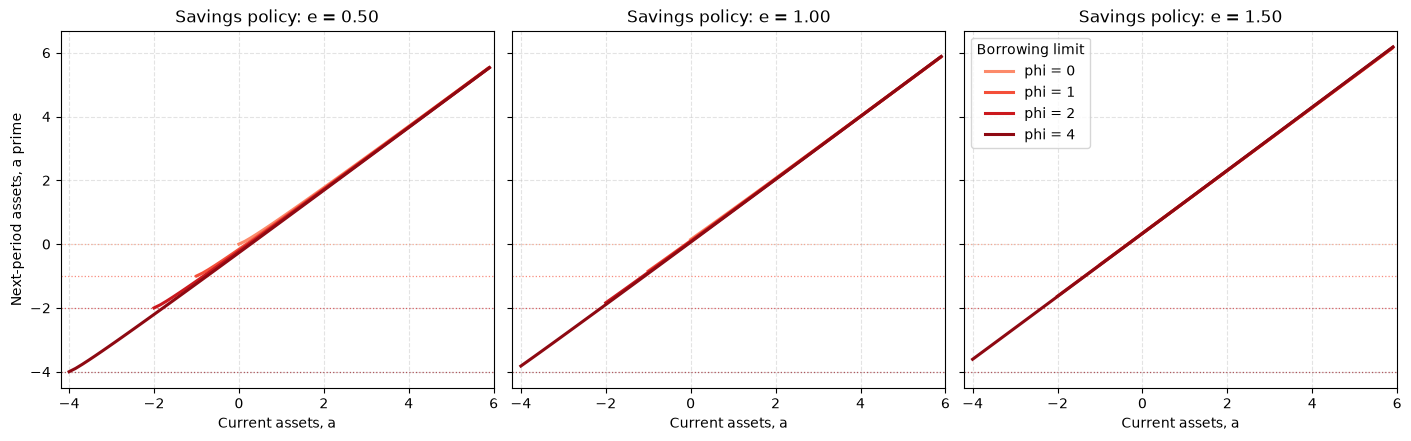

In [9]:
# Savings policies across phi: zoom around the borrowing region
fig, axes = plt.subplots(1, 3, figsize=(14, 4.3), sharey=True, constrained_layout=True)
for ax, i_s in zip(axes, selected_states):
    for phi, color in zip(phi_values, ge_colors):
        K_eq, w_eq, A_eq, constrained_share, a_grid_phi, a_pol, c_pol, dist = ge_solutions[float(phi)]
        visible = a_grid_phi <= 6.0
        ax.plot(a_grid_phi[visible], a_pol[visible, i_s], color=color, lw=2.2,
                label=f'phi = {phi:.0f}')
        ax.axhline(-phi, color=color, ls=':', lw=0.9, alpha=0.65)
    ax.set(title=f'Savings policy: e = {e_grid[i_s]:.2f}',
           xlabel='Current assets, a', xlim=(-4.2, 6.0))
    ax.grid(alpha=0.35, ls='--')
axes[0].set_ylabel('Next-period assets, a prime')
axes[-1].legend(title='Borrowing limit')
plt.show()


### Interpretation: savings policies across $\phi$

The dotted horizontal lines are the scenario-specific borrowing limits. As $\phi$ rises, households can choose lower next-period asset positions, so the constrained portions of the policies move downward. The slope and location of each curve away from the limit also change because prices are re-equilibrated. Comparing the three panels shows that the effect is strongest in low-efficiency states, where borrowing is most valuable for consumption smoothing.

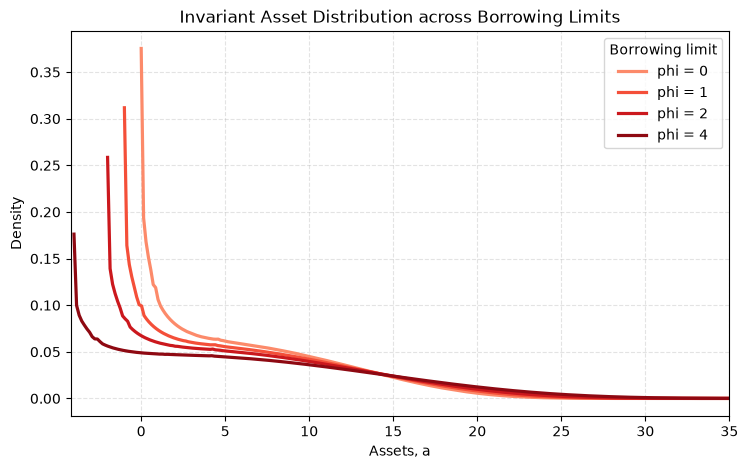

In [10]:
# Unconditional invariant asset distributions across phi
fig, ax = plt.subplots(figsize=(8.5, 5))
for phi, color in zip(phi_values, ge_colors):
    K_eq, w_eq, A_eq, constrained_share, a_grid_phi, a_pol, c_pol, dist = ge_solutions[float(phi)]
    asset_density = dist.sum(axis=1) / (a_grid_phi[1] - a_grid_phi[0])
    visible = a_grid_phi <= 35.0
    ax.plot(a_grid_phi[visible], asset_density[visible], color=color, lw=2.3,
            label=f'phi = {phi:.0f}')
ax.set(title='Invariant Asset Distribution across Borrowing Limits',
       xlabel='Assets, a', ylabel='Density', xlim=(-4.2, 35.0))
ax.grid(alpha=0.35, ls='--')
ax.legend(title='Borrowing limit')
plt.show()


### Interpretation: invariant asset distribution across $\phi$

Unlike the earlier conditional-distribution figure, this plot aggregates over all income states and therefore displays the economy-wide wealth distribution. A relaxed limit allows the support of the distribution to extend further into negative assets and typically shifts mass toward lower asset levels. This is the distributional counterpart to the fall in aggregate capital. It is more informative than only reporting the fraction exactly at the borrowing limit, because that fraction changes mechanically when the location of the limit itself changes.

## References and course materials

Aiyagari, S. Rao (1994). *Uninsured Idiosyncratic Risk and Aggregate Saving*. **The Quarterly Journal of Economics**, 109(3), 659–684. https://doi.org/10.2307/2118417

Carroll, Christopher D. (2006). *The Method of Endogenous Gridpoints for Solving Dynamic Stochastic Optimization Problems*. **Economics Letters**, 91(3), 312–320. https://doi.org/10.1016/j.econlet.2005.09.013

Martinez, Tomás R. (n.d.). *Advanced Macro: Quantitative Macro with Heterogeneous Agents*. Insper. Course page. Available at: https://tomasrm.github.io/teaching/advmacro/ (accessed 8 September 2026).

Martinez, Tomás R. (n.d.). *Bewley-Huggett-Aiyagari-Imrohoroglu Model*. Advanced Macroeconomics lecture notes, Insper. Available at: https://tomasrm.github.io/teaching/advmacro/aiyagari.pdf (accessed 8 September 2026).

Martinez, Tomás R. (n.d.). *Computational Aspects of the Aiyagari Model*. Advanced Macroeconomics lecture notes, Insper. Available at: https://tomasrm.github.io/teaching/advmacro/aiyagari_computational.pdf (accessed 8 September 2026).

Martinez, Tomás R. (n.d.). *Notebook and Code for the Solution Using EGM (in Python)*. Advanced Macro course materials, Insper. Available through the course page above (accessed 8 September 2026).

These materials motivated the notation, the stationary-distribution discussion, and the EGM implementation in this notebook.